# Initialization

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import time

## Simulation parameters

In [2]:
Fc = 1.57542e9 #457e3          # The carrier frequency
Rc = 1.023e6 #Fc/5 #1.023e6        # L1 chip rate
Fs = 20*Rc         # sampling rate (must be >> Rc)

alpha = 0.35        # roll-off factor
span = 6            # filter span in symbols

# Transmitter

## Generate PRN sequence
- Create a 1023-element PRN [Gold code](https://en.wikipedia.org/wiki/Gold_code).

In [3]:
import numpy as np

#######################
# GOLD CODE GENERATOR #
#######################

def generate_ca_code(prn):
    """
    Generate 1023-chip GPS L1 C/A Gold code for given PRN (1–32)
    Returns array of 0/1 values.
    """

    # G2 tap selections for PRNs 1–32
    g2_taps = {
        1: (2, 6),  2: (3, 7),  3: (4, 8),  4: (5, 9),
        5: (1, 9),  6: (2,10),  7: (1, 8),  8: (2, 9),
        9: (3,10), 10: (2, 3), 11: (3, 4), 12: (5, 6),
        13:(6, 7), 14:(7, 8), 15:(8, 9), 16:(9,10),
        17:(1, 4), 18:(2, 5), 19:(3, 6), 20:(4, 7),
        21:(5, 8), 22:(6, 9), 23:(1, 3), 24:(4, 6),
        25:(5, 7), 26:(6, 8), 27:(7, 9), 28:(8,10),
        29:(1, 6), 30:(2, 7), 31:(3, 8), 32:(4, 9)
    }

    if prn not in g2_taps:
        raise ValueError("PRN must be between 1 and 32")

    # Initialize registers (all ones)
    g1 = np.ones(10, dtype=int)
    g2 = np.ones(10, dtype=int)

    code = np.zeros(1023, dtype=int)

    tap1, tap2 = g2_taps[prn]

    for i in range(1023):

        # Output
        g1_out = g1[-1]
        g2_out = g2[tap1-1] ^ g2[tap2-1]
        code[i] = g1_out ^ g2_out

        # Feedback
        g1_feedback = g1[2] ^ g1[9]
        g2_feedback = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]

        # Shift registers
        g1[1:] = g1[:-1]
        g1[0] = g1_feedback

        g2[1:] = g2[:-1]
        g2[0] = g2_feedback

    return code

##########################
# GENERATE THE GOLD CODE #
##########################

seed = 1
ca = generate_ca_code(seed)
ca_bpsk = 2*ca - 1
print(f"Created a Gold code of length {len(ca_bpsk)} with the seed value '{seed}'")

Created a Gold code of length 1023 with the seed value '1'


## Modulate the PRN
- Consider using a raised cosine pulse to make the pulse more realistic
- The chip rate dictates the bandwidth

$\text{samples\_per\_chip} = \frac{\text{samples}}{\text{second}} \cdot \frac{\text{seconds}}{\text{chip}}$

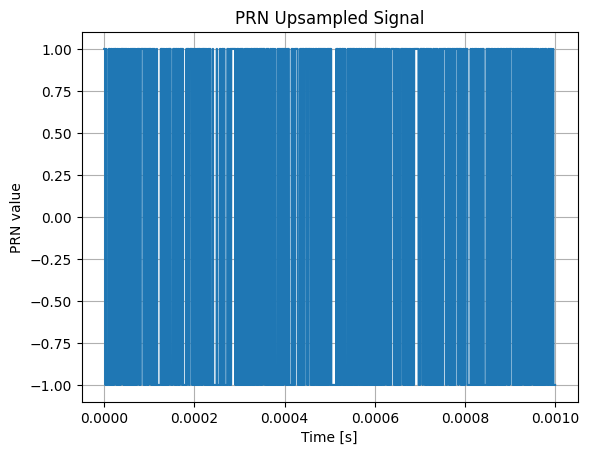

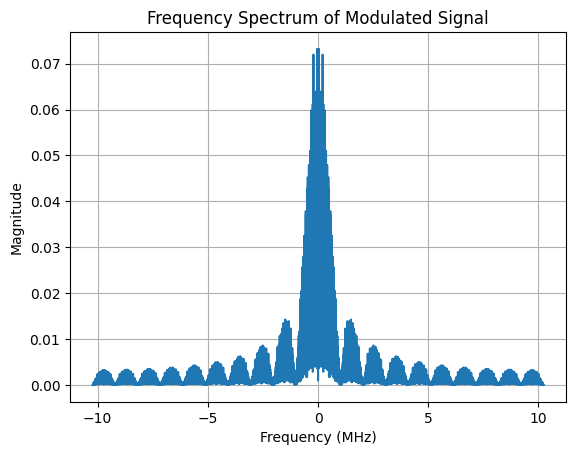

Null-to-null bandwidth: 20.458 MHz


In [4]:
samples_per_chip = int(Fs / Rc)

# Create a sequence where each element in the PRN repeats samples_per_chip times
signal = np.repeat(ca_bpsk, samples_per_chip)

# plt.plot(t, signal)
# plt.xlabel("Time [s]")
# plt.ylabel("PRN value")
# plt.title("PRN Upsampled Signal")

# Create the time value for each sample (t = 0, 1/Fs, 2/Fs, etc)
t = np.arange(len(signal)) / Fs

# Modulate the signal onto the carrier signal
rf = signal * np.cos(2*np.pi*Fc*t)

# Calculate the frequency spectrum of the modulated signal
frequency_domain_signal = np.fft.fft(rf)

# Center the spectrum around 0 Hz
S = np.fft.fftshift(frequency_domain_signal)

# Generate the frequency axis
freq = np.fft.fftshift(np.fft.fftfreq(len(rf), 1/Fs))

# --- Time-domain PRN Signal ---
plt.figure()  # new figure
plt.plot(t, signal)
plt.xlabel("Time [s]")
plt.ylabel("PRN value")
plt.title("PRN Upsampled Signal")
plt.grid(True)

# --- Frequency-domain RF Signal ---
plt.figure()  # new figure
plt.plot(freq/1e6, np.abs(S)/len(S))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum of Modulated Signal")
plt.grid(True)

plt.show()

#############
# BANDWIDTH #
#############
"""
# Use the upsampled PRN signal
power_bb = np.abs(np.fft.fftshift(np.fft.fft(signal)))**2
freq_bb = np.fft.fftshift(np.fft.fftfreq(len(signal), 1/Fs))

half_power = np.max(power_bb)/2
indices = np.where(power_bb > half_power)[0]

bw_3db = freq_bb[indices[-1]] - freq_bb[indices[0]]
print(f"3 dB bandwidth (baseband): {bw_3db/1e6:.3f} MHz")
"""
"""
power = np.abs(S)**2

half_power = np.max(power) / 2

indices = np.where(power > half_power)[0]

bw_3db = freq[indices[-1]] - freq[indices[0]]
print(f"3 dB bandwidth: {bw_3db/1e6} MHz.")
"""
"""
f = np.linspace(-5*Rc, 5*Rc, 1000)
spectrum = np.abs(np.sinc(f / Rc))  # sinc(x) = sin(pi x)/(pi x)
plt.plot(f/1e6, spectrum)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.title("Theoretical PRN spectrum")
plt.grid(True)
plt.show()
"""

# Find first zero crossings (nulls) of the sinc
freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), 1/Fs))
spectrum = np.abs(np.fft.fftshift(np.fft.fft(signal)))

# Normalize
spectrum /= np.max(spectrum)

# Find where spectrum first drops below a small threshold (e.g., 1e-6)
threshold = 1e-6
indices = np.where(spectrum > threshold)[0]

bw_null_to_null = freqs[indices[-1]] - freqs[indices[0]]
print(f"Null-to-null bandwidth: {bw_null_to_null/1e6:.3f} MHz")

In [5]:
# Upsampled PRN
samples_per_chip = int(Fs / Rc)
signal_up = np.repeat(ca_bpsk, samples_per_chip)

# RF signal
t = np.arange(len(signal_up)) / Fs
rf = signal_up * np.cos(2*np.pi*Fc*t)

# FFT
N = len(rf)
S = np.fft.fftshift(np.fft.fft(rf, 2**18))  # zero-pad for high resolution
freqs = np.fft.fftshift(np.fft.fftfreq(len(S), 1/Fs))

# Normalize
S_mag = np.abs(S)/np.max(np.abs(S))

# Null-to-null: first points where spectrum drops below tiny fraction (~1e-4)
threshold = 1e-4
indices = np.where(S_mag > threshold)[0]

bw_null_to_null = freqs[indices[-1]] - freqs[indices[0]]
print(f"Measured RF null-to-null bandwidth: {bw_null_to_null/1e6:.3f} MHz")

Measured RF null-to-null bandwidth: 20.455 MHz


# Receiver

## Downconvert (I/Q)
- Mix the signal with a local oscillator to bring it to a baseband centered at 0 Hz
- In-phase / quadrature demodulation retains phase information I think?

We need to multiply the modulated signal by another sinusoid to demodulate it. This is consistent with the following trigonometric identity:

$$
\begin{aligned}
\cos(a)\cos(b) &= \frac{1}{2}[\cos(a-b)+\cos(a+b)] \\
\therefore C(t)\cos(2 \pi f_c t)\cos(2 \pi f_c t) &= \frac{1}{2} C(t) [\cos(2 \pi f_c t - 2 \pi f_c t) + \cos(2 \pi f_c t + 2 \pi f_c t)] \\
&= \frac{1}{2} C(t) [1 + \cos(4 \pi f_c t)] \\
&= \frac{1}{2} C(t) + \frac{1}{2} C(t) \cos(4 \pi f_c t)
\end{aligned}
$$

Now we can apply a low-pass filter to remove the $ \frac{1}{2} C(t) \cos(4 \pi f_c t) $ term, multiply by $2$, and we get $C(t)$.

Text(0, 0.5, 'Reconstructed PRN value')

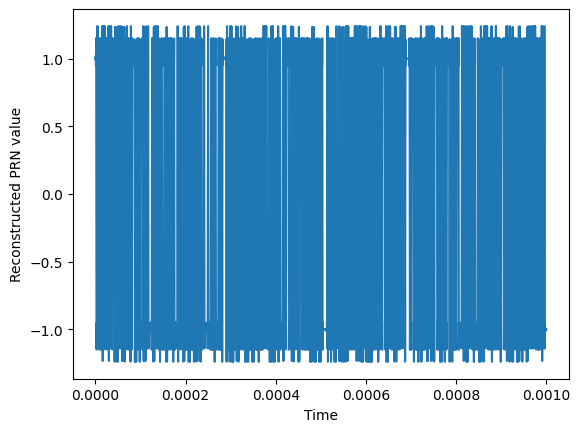

In [6]:
demodulated_signal = rf * np.cos(2*np.pi*Fc*t)

# Cutoff frequency (must be > message bandwidth but << Fc)
cutoff = 1.2*Rc  

# A Butterworth low-pass filter, which takes in the Nyquist frequency (Fs/2)
b, a = butter(5, cutoff/(Fs/2), btype='low')
baseband = filtfilt(b, a, demodulated_signal)

plt.plot(t, baseband)
plt.xlabel("Time")
plt.ylabel("Reconstructed PRN value")

Next, I want to rebuild the original upsampled PRN sequence, so I set values greater than 0 to 1 and values less than 0 to -1.

Number of differing samples: 0
Error: 0.000%


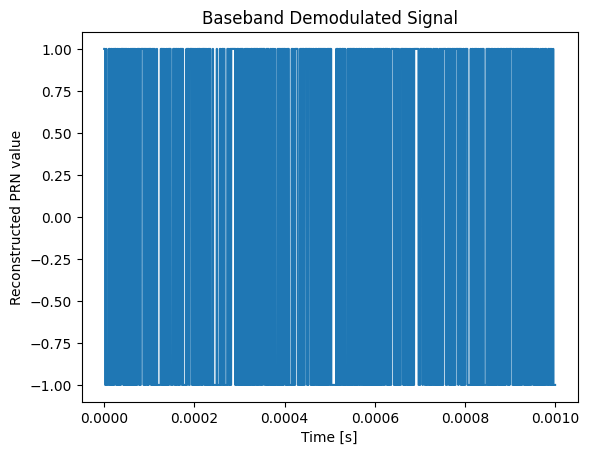

In [7]:
# baseband is your demodulated signal
reconstructed_signal = np.sign(baseband)  # outputs -1 for negative, 0 for zero, +1 for positive

plt.plot(t, reconstructed_signal)
plt.xlabel("Time [s]")
plt.ylabel("Reconstructed PRN value")
plt.title("Baseband Demodulated Signal")

num_errors = np.sum(reconstructed_signal != signal)
print(f"Number of differing samples: {num_errors}")
print(f"Error: {num_errors / len(signal) * 100:.3f}%")

## Correllate with local PRN replicas

At a sampling frequency of 20460000.0 samples/s, the correllation took 1.45 ms.


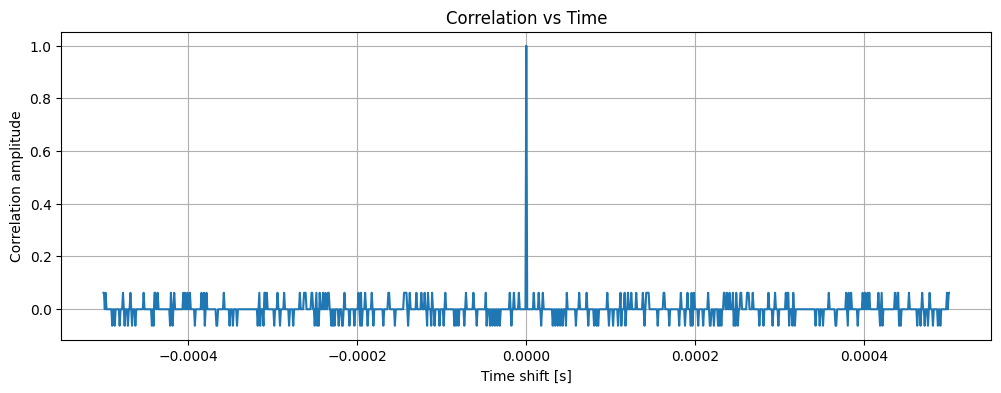

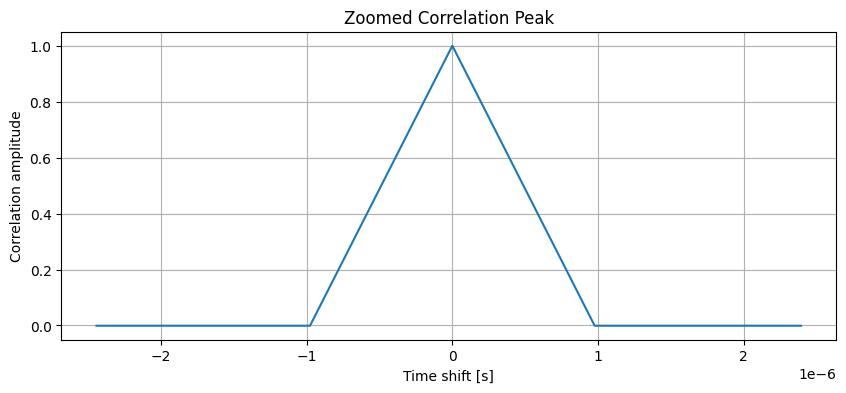

Time resolution per correlation step: 48.88 ns
Approximate correlation peak FWHM: 928.64 ns
This corresponds to an accuracy within 278.592 meters.


In [8]:
###########
# REPLICA #
###########

shift_amount = range(-(len(signal)//2), (len(signal)//2))
correlation_sum = []

###############
# CORRELATION #
###############

start = time.time()

"""
# This was my original correlation code, which worked but was magnitudes slower

for shift in shift_amount:
    replica = np.roll(signal, shift)
    
    result = replica * reconstructed_signal
    
    # Normalize the peaks for visual intuitiveness
    correlation_sum.append(np.sum(result) / len(signal))
"""

correlation_sum = np.fft.ifft(
    np.fft.fft(reconstructed_signal) * np.conj(np.fft.fft(signal))
).real / len(signal)

correlation_sum = np.fft.fftshift(correlation_sum)

shift_amount = np.arange(-len(signal)//2, len(signal)//2)


end = time.time()

print(f"At a sampling frequency of {Fs} samples/s, the correllation took {(end-start)*1e3:.2f} ms.")

time_shift = np.array(shift_amount) / Fs  # in seconds

#########
# PLOTS #
#########

# Full correlation vs time
plt.figure(figsize=(12,4))
plt.plot(time_shift, correlation_sum)
plt.title("Correlation vs Time")
plt.xlabel("Time shift [s]")
plt.ylabel("Correlation amplitude")
plt.grid(True)
plt.show()

# Zoom in on the correlation peak
peak_index = np.argmax(correlation_sum)
window = 50  # number of samples around the peak to zoom
plt.figure(figsize=(10,4))
plt.plot(time_shift[peak_index-window:peak_index+window],
         correlation_sum[peak_index-window:peak_index+window])
plt.title("Zoomed Correlation Peak")
plt.xlabel("Time shift [s]")
plt.ylabel("Correlation amplitude")
plt.grid(True)
plt.show()

###################
# TIME RESOLUTION #
###################

time_resolution = 1 / Fs  # seconds per sample
print(f"Time resolution per correlation step: {time_resolution*1e9:.2f} ns")

# Optional: estimate FWHM (width of correlation peak)
half_max = np.max(correlation_sum) / 2
indices_above_half = np.where(correlation_sum >= half_max)[0]
fwhm_samples = indices_above_half[-1] - indices_above_half[0] + 1
fwhm_time = fwhm_samples / Fs
print(f"Approximate correlation peak FWHM: {fwhm_time*1e9:.2f} ns")
print(f"This corresponds to an accuracy within {3e8 * fwhm_time:.3f} meters.")

## Results

At 
```
Rc = 1.023e6        # L1 chip rate
Fs = 50*1.023e6     # sampling rate (must be >> Rc)
Fc = 457e3          # The carrier frequency
```
The resolution is 19.55 ns.

At 
```
Rc = 1.023e6        # L1 chip rate
Fs = 40*1.023e6     # sampling rate (must be >> Rc)
Fc = 457e3          # The carrier frequency
```
The resolution is 24.44 ns.

At 
```
Rc = 1.023e6        # L1 chip rate
Fs = 30*1.023e6     # sampling rate (must be >> Rc)
Fc = 457e3          # The carrier frequency
```
The resolution is 32.58 ns.

At 
```
Rc = 1.023e6        # L1 chip rate
Fs = 20*1.023e6     # sampling rate (must be >> Rc)
Fc = 457e3          # The carrier frequency
```
The resolution is 48.88 ns.

## Questions
- How does [chip rate relate to carrier frequency](https://www.irisoele.com/en/technology/column/detarate/)?
  - The chip rate must be a subharmonic of the carrier frequency. For example, in L1, the chip rate is 1.023 MHz and the carrier frequency is 1575.42 MHz. 1575.42 MHz / 1.023 MHz = 1540 **exactly**.